In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, validation_curve,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True


## 1) Dados e dispersão treino×teste

Usando df existente no ambiente (x1, x2, y).


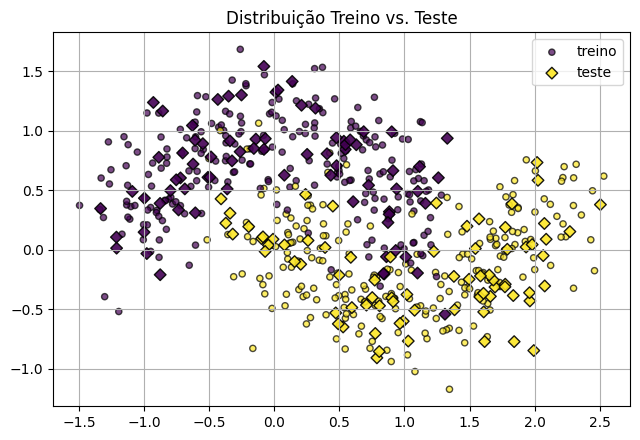

In [20]:
# Se não existir df, gera com make_moons
if 'df' not in globals():
    from sklearn.datasets import make_moons
    X, y = make_moons(n_samples=600, noise=0.25, random_state=42)
    df = pd.DataFrame({
        'x1': X[:, 0],
        'x2': X[:, 1],
        'y': y,
        'label': np.where(y == 0, 'Lua A', 'Lua B')
    })
    print('Prévia do df gerado:')
    display(df.head())
else:
    print('Usando df existente no ambiente (x1, x2, y).')

X = df[['x1','x2']].to_numpy()
y = df['y'].to_numpy()

# Split estratificado
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Dispersão treino×teste
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
ax.scatter(X_tr[:,0], X_tr[:,1], c=y_tr, s=20, marker='o', edgecolor='k', alpha=0.7, label='treino')
ax.scatter(X_te[:,0], X_te[:,1], c=y_te, s=35, marker='D', edgecolor='k', alpha=0.9, label='teste')
ax.set_title('Distribuição Treino vs. Teste'); ax.legend()
plt.tight_layout(); plt.show()

## 2) Pipelines, grades e buscas (CV com F1)

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Regressão Logística (L1/L2)
pipe_lr = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(solver='saga', max_iter=5000, tol=1e-4))])

grid_lr = {'clf__penalty': ['l1','l2'],
           'clf__C': [1e-3, 1e-2, 1e-1, 1, 10, 100]}

gs_lr = GridSearchCV(pipe_lr, grid_lr, scoring='f1', cv=cv, n_jobs=-1)
gs_lr.fit(X_tr, y_tr)
best_lr = gs_lr.best_estimator_

# SVM RBF
pipe_svm = Pipeline([('scaler', StandardScaler()),
                     ('clf', SVC(kernel='rbf', probability=True))])

grid_svm = {'clf__C': [0.1, 1, 10, 100],
            'clf__gamma': [0.001, 0.01, 0.1, 1.0]}

gs_svm = GridSearchCV(pipe_svm, grid_svm, scoring='f1', cv=cv, n_jobs=-1)
gs_svm.fit(X_tr, y_tr)
best_svm = gs_svm.best_estimator_

print('Melhores hiperparâmetros (LR): ', gs_lr.best_params_)
print('Melhores hiperparâmetros (SVM):', gs_svm.best_params_)

Melhores hiperparâmetros (LR):  {'clf__C': 0.1, 'clf__penalty': 'l1'}
Melhores hiperparâmetros (SVM): {'clf__C': 100, 'clf__gamma': 1.0}


## 3) Avaliação no teste

In [22]:
def avalia(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy': accuracy_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC_AUC': roc_auc_score(y_te, y_proba),
        'PR_AUC': average_precision_score(y_te, y_proba),
        'cm': confusion_matrix(y_te, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

res_lr  = avalia(best_lr,  X_te, y_te)
res_svm = avalia(best_svm, X_te, y_te)

print('Teste (LR) :', {k: round(v, 3) for k,v in res_lr.items() if k not in ['cm','y_pred','y_proba']})
print('Teste (SVM):', {k: round(v, 3) for k,v in res_svm.items() if k not in ['cm','y_pred','y_proba']})

Teste (LR) : {'Accuracy': 0.867, 'F1': 0.87, 'ROC_AUC': 0.939, 'PR_AUC': 0.928}
Teste (SVM): {'Accuracy': 0.947, 'F1': 0.947, 'ROC_AUC': 0.981, 'PR_AUC': 0.975}


## 4) Heatmaps das grades — subplots

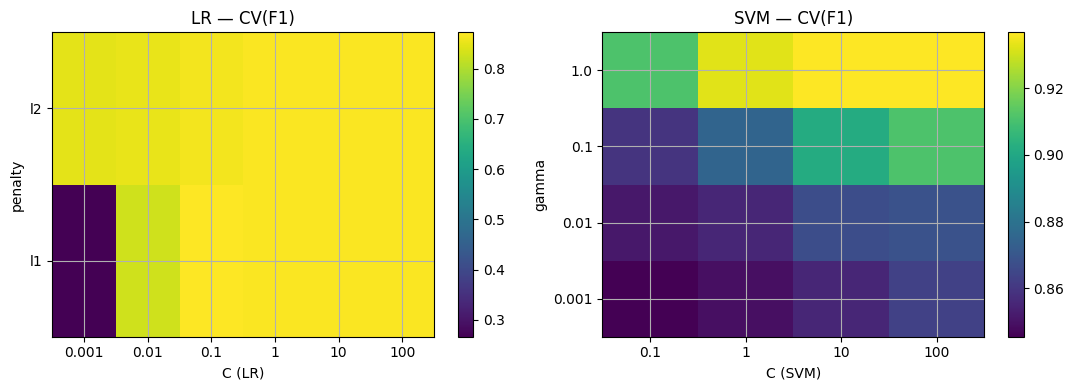

In [23]:
def heatmap(ax, M, xs, ys, xlabel, ylabel, title):
    im = ax.imshow(M, origin='lower', aspect='auto')
    ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs)
    ax.set_yticks(range(len(ys))); ax.set_yticklabels(ys)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    plt.colorbar(im, ax=ax)

def extrai_mapa_lr(gs, Cs, penalties):
    M = np.zeros((len(penalties), len(Cs)))
    for i, p in enumerate(penalties):
        for j, c in enumerate(Cs):
            mask = (gs.cv_results_['param_clf__penalty'] == p) & (gs.cv_results_['param_clf__C'] == c)
            M[i, j] = gs.cv_results_['mean_test_score'][mask][0]
    return M

def extrai_mapa_svm(gs, Cs, gammas):
    M = np.zeros((len(gammas), len(Cs)))
    for i, g in enumerate(gammas):
        for j, c in enumerate(Cs):
            mask = (gs.cv_results_['param_clf__gamma'] == g) & (gs.cv_results_['param_clf__C'] == c)
            M[i, j] = gs.cv_results_['mean_test_score'][mask][0]
    return M

Cs_lr = [1e-3, 1e-2, 1e-1, 1, 10, 100]; penalties = ['l1','l2']
Cs_svm = [0.1, 1, 10, 100]; gammas = [0.001, 0.01, 0.1, 1.0]

mapa_lr = extrai_mapa_lr(gs_lr, Cs_lr, penalties)
mapa_svm = extrai_mapa_svm(gs_svm, Cs_svm, gammas)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
heatmap(axs[0], mapa_lr, Cs_lr, penalties, 'C (LR)', 'penalty', 'LR — CV(F1)')
heatmap(axs[1], mapa_svm, Cs_svm, gammas, 'C (SVM)', 'gamma', 'SVM — CV(F1)')
plt.tight_layout(); plt.show()

## 5) Fronteiras de decisão — 3 subplots (LR-L1, LR-L2, SVM)

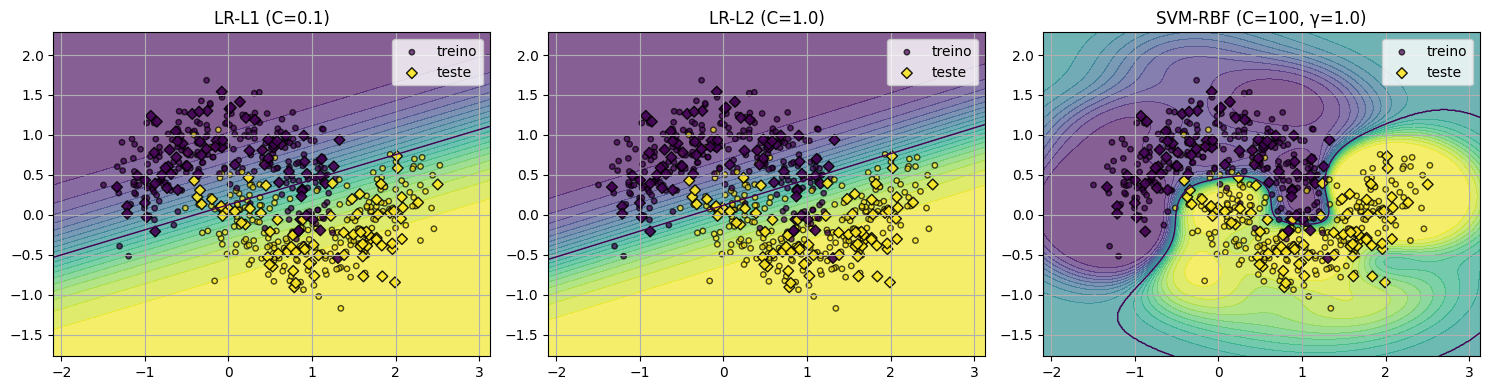

In [24]:
def fronteira(ax, model, X_tr, y_tr, X_te, y_te, title):
    x1_min, x1_max = X_tr[:, 0].min() - 0.6, X_tr[:, 0].max() + 0.6
    x2_min, x2_max = X_tr[:, 1].min() - 0.6, X_tr[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 400),
                         np.linspace(x2_min, x2_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, alpha=0.65)
    ax.contour(xx, yy, Z, levels=[0.5], linewidths=1.0)
    ax.scatter(X_tr[:,0], X_tr[:,1], c=y_tr, s=15, marker='o', edgecolor='k', alpha=0.7, label='treino')
    ax.scatter(X_te[:,0], X_te[:,1], c=y_te, s=30, marker='D', edgecolor='k', alpha=0.9, label='teste')
    ax.set_title(title); ax.legend()

# Reconstruir LR-L1 e LR-L2 usando o melhor C de cada penalidade
def melhor_C_por_penalty(gs, penalty):
    mask = (gs.cv_results_['param_clf__penalty'] == penalty)
    idx = np.argmax(gs.cv_results_['mean_test_score'][mask])
    Cs_vals = gs.cv_results_['param_clf__C'][mask]
    return float(Cs_vals[idx])

bestC_l1 = melhor_C_por_penalty(gs_lr, 'l1')
bestC_l2 = melhor_C_por_penalty(gs_lr, 'l2')

lr_l1 = Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(penalty='l1', C=bestC_l1, solver='saga', max_iter=5000, tol=1e-4))]).fit(X_tr, y_tr)
lr_l2 = Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(penalty='l2', C=bestC_l2, solver='saga', max_iter=5000, tol=1e-4))]).fit(X_tr, y_tr)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fronteira(axs[0], lr_l1,  X_tr, y_tr, X_te, y_te, f'LR-L1 (C={bestC_l1})')
fronteira(axs[1], lr_l2,  X_tr, y_tr, X_te, y_te, f'LR-L2 (C={bestC_l2})')
fronteira(axs[2], best_svm, X_tr, y_tr, X_te, y_te,
          f'SVM-RBF (C={gs_svm.best_params_["clf__C"]}, γ={gs_svm.best_params_["clf__gamma"]})')
plt.tight_layout(); plt.show()

## 6) Curvas ROC e PR — subplots

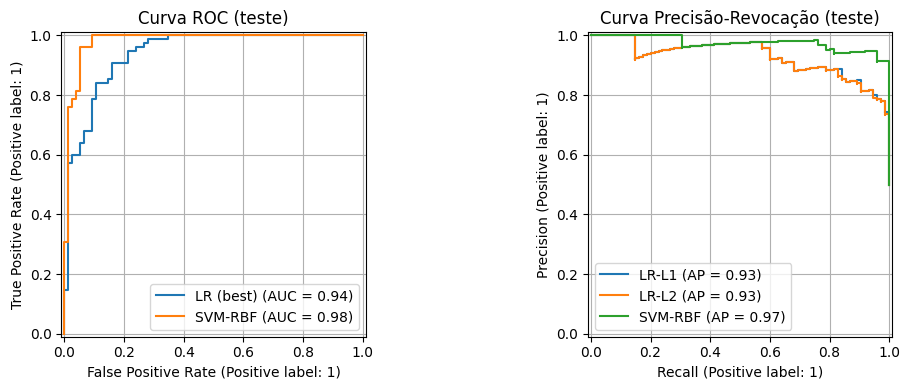

In [25]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(11, 4))

# ROC — comparação direta
RocCurveDisplay.from_estimator(best_lr,  X_te, y_te, ax=ax_roc, name='LR (best)')
RocCurveDisplay.from_estimator(best_svm, X_te, y_te, ax=ax_roc, name='SVM-RBF')
ax_roc.set_title('Curva ROC (teste)')

# PR — LR-L1, LR-L2 e SVM
PrecisionRecallDisplay.from_estimator(lr_l1,   X_te, y_te, ax=ax_pr, name='LR-L1')
PrecisionRecallDisplay.from_estimator(lr_l2,   X_te, y_te, ax=ax_pr, name='LR-L2')
PrecisionRecallDisplay.from_estimator(best_svm, X_te, y_te, ax=ax_pr, name='SVM-RBF')
ax_pr.set_title('Curva Precisão-Revocação (teste)')

plt.tight_layout(); plt.show()

## 7) Matrizes de confusão — subplots

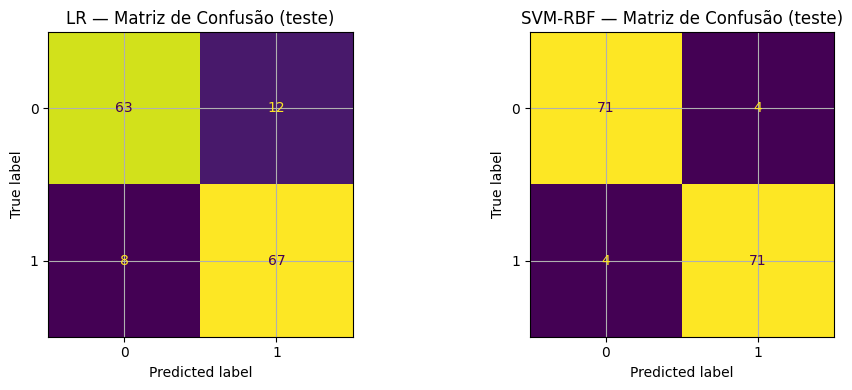

In [26]:
cm_lr  = confusion_matrix(y_te, best_lr.predict(X_te))
cm_svm = confusion_matrix(y_te, best_svm.predict(X_te))

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_lr).plot(ax=axs[0], colorbar=False)
axs[0].set_title('LR — Matriz de Confusão (teste)')
ConfusionMatrixDisplay(cm_svm).plot(ax=axs[1], colorbar=False)
axs[1].set_title('SVM-RBF — Matriz de Confusão (teste)')
plt.tight_layout(); plt.show()

## 8) Caminhos dos coeficientes (LR-L1 vs LR-L2) — subplots

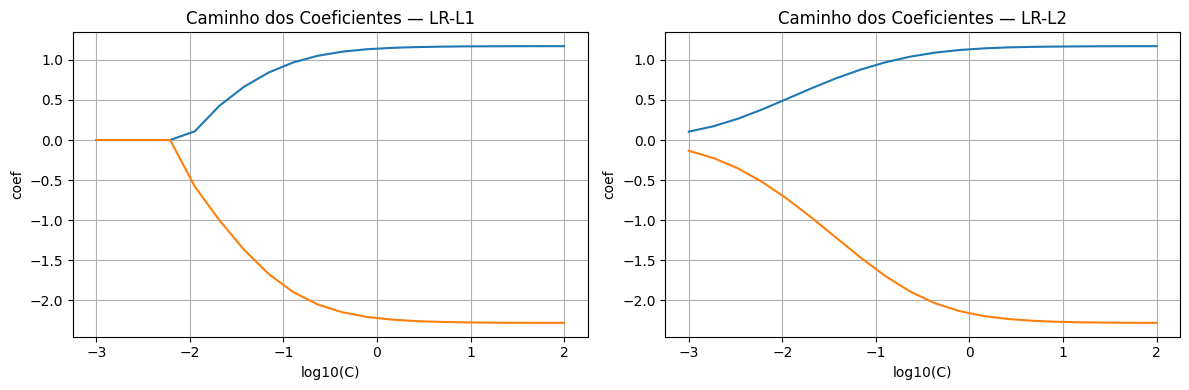

In [27]:
def caminho_coef(penalty, X_tr, y_tr):
    Cs = np.logspace(-3, 2, 20)
    coefs = []
    for C in Cs:
        mdl = Pipeline([('scaler', StandardScaler()),
                        ('clf', LogisticRegression(penalty=penalty, C=C, solver='saga',
                                                   max_iter=5000, tol=1e-4))]).fit(X_tr, y_tr)
        coefs.append(mdl.named_steps['clf'].coef_.ravel())
    return np.log10(Cs), np.array(coefs)

logC_l1, coef_l1 = caminho_coef('l1', X_tr, y_tr)
logC_l2, coef_l2 = caminho_coef('l2', X_tr, y_tr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for k in range(coef_l1.shape[1]):
    ax1.plot(logC_l1, coef_l1[:, k])
ax1.set_title('Caminho dos Coeficientes — LR-L1'); ax1.set_xlabel('log10(C)'); ax1.set_ylabel('coef')

for k in range(coef_l2.shape[1]):
    ax2.plot(logC_l2, coef_l2[:, k])
ax2.set_title('Caminho dos Coeficientes — LR-L2'); ax2.set_xlabel('log10(C)'); ax2.set_ylabel('coef')

plt.tight_layout(); plt.show()

## 9) Curvas de validação (SVM: gamma e C) — subplots

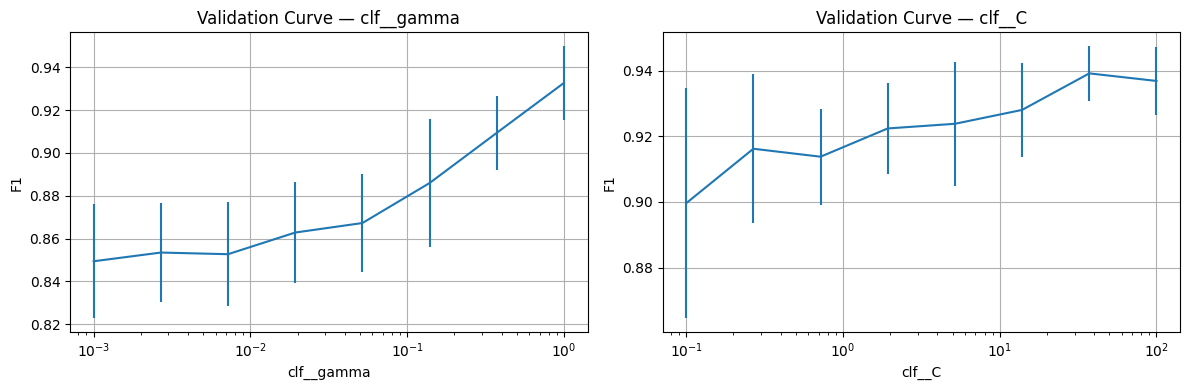

In [28]:
def plot_validation_curve(param_name, param_range, ax):
    model = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', probability=True))])
    cv_local = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    tr, te = validation_curve(model, X_tr, y_tr,
                              param_name=param_name, param_range=param_range,
                              cv=cv_local, scoring='f1', n_jobs=-1)
    mu, sd = te.mean(axis=1), te.std(axis=1)
    ax.errorbar(param_range, mu, yerr=sd)
    ax.set_xscale('log'); ax.set_xlabel(param_name); ax.set_ylabel('F1')
    ax.set_title(f'Validation Curve — {param_name}')

fig, (ax_g, ax_c) = plt.subplots(1, 2, figsize=(12, 4))
plot_validation_curve('clf__gamma', np.logspace(-3, 0, 8), ax_g)
plot_validation_curve('clf__C',     np.logspace(-1, 2, 8), ax_c)
plt.tight_layout(); plt.show()

## 10) Curvas de aprendizado (LR vs SVM) — subplots

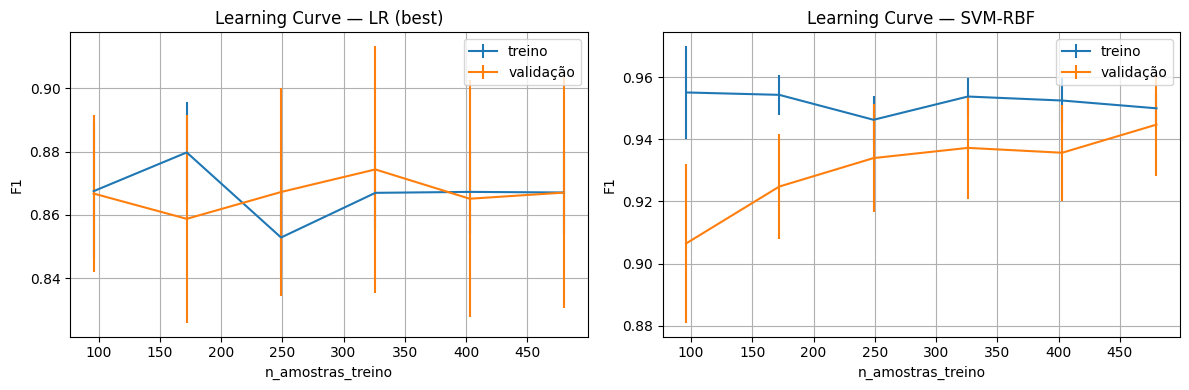

In [29]:
def plot_learning_curve(model, X, y, ax, title):
    cv_local = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sizes, tr, te = learning_curve(model, X, y, cv=cv_local, scoring='f1',
                                   n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 6))
    mu_tr, sd_tr = tr.mean(axis=1), tr.std(axis=1)
    mu_te, sd_te = te.mean(axis=1), te.std(axis=1)
    ax.errorbar(sizes, mu_tr, yerr=sd_tr, label='treino')
    ax.errorbar(sizes, mu_te, yerr=sd_te, label='validação')
    ax.set_title(title); ax.set_xlabel('n_amostras_treino'); ax.set_ylabel('F1'); ax.legend()

fig, (ax_lr, ax_svm) = plt.subplots(1, 2, figsize=(12, 4))
plot_learning_curve(best_lr,  X, y, ax_lr,  'Learning Curve — LR (best)')
plot_learning_curve(best_svm, X, y, ax_svm, 'Learning Curve — SVM-RBF')
plt.tight_layout(); plt.show()

## 11) Calibração (reliability) — subplots

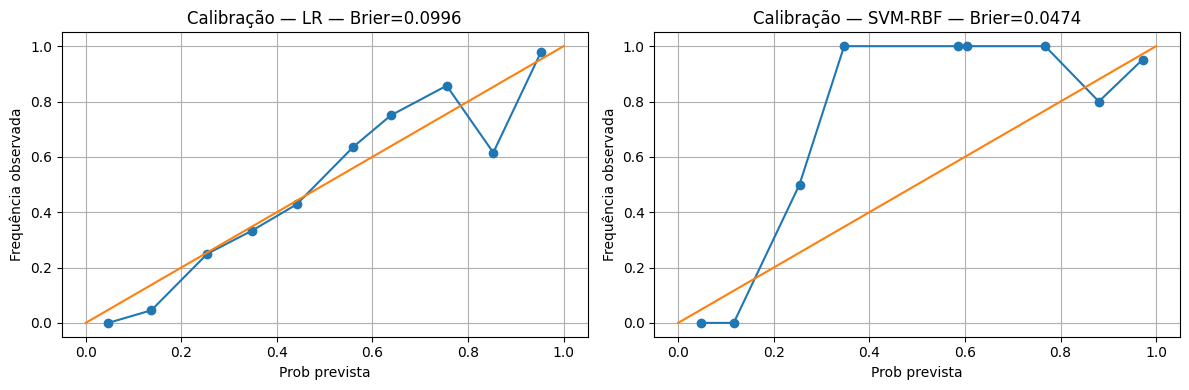

In [30]:
def calib_subplot(ax, model, X_te, y_te, title):
    prob = model.predict_proba(X_te)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_te, prob, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, marker='o', label='modelo')
    ax.plot([0,1],[0,1])
    bs = brier_score_loss(y_te, prob)
    ax.set_title(f'{title} — Brier={bs:.4f}')
    ax.set_xlabel('Prob prevista'); ax.set_ylabel('Frequência observada')

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 4))
calib_subplot(ax_a, best_lr,  X_te, y_te, 'Calibração — LR')
calib_subplot(ax_b, best_svm, X_te, y_te, 'Calibração — SVM-RBF')
plt.tight_layout(); plt.show()

## 12) Distribuição de probabilidades por classe — subplots

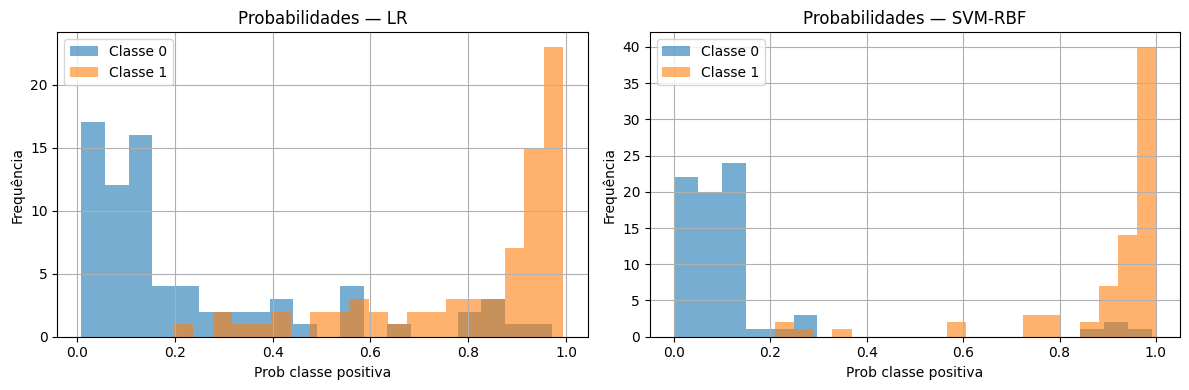

In [31]:
def hist_probs_subplot(ax, model, X_te, y_te, title):
    prob = model.predict_proba(X_te)[:, 1]
    ax.hist(prob[y_te==0], bins=20, alpha=0.6, label='Classe 0')
    ax.hist(prob[y_te==1], bins=20, alpha=0.6, label='Classe 1')
    ax.set_title(title); ax.set_xlabel('Prob classe positiva'); ax.set_ylabel('Frequência')
    ax.legend()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
hist_probs_subplot(ax1, best_lr,  X_te, y_te, 'Probabilidades — LR')
hist_probs_subplot(ax2, best_svm, X_te, y_te, 'Probabilidades — SVM-RBF')
plt.tight_layout(); plt.show()

## 13) Margens (SVM) vs Probabilidades (LR) — subplots

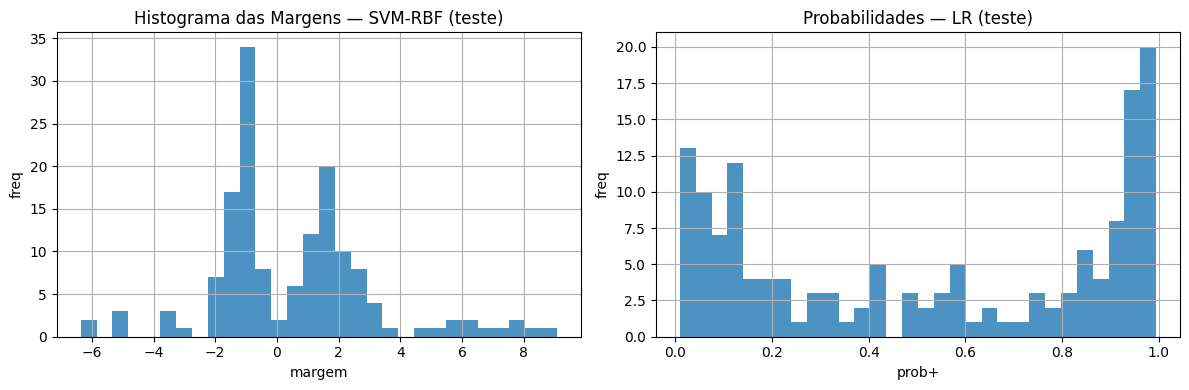

In [32]:
margins_svm = best_svm.decision_function(X_te)
prob_lr = best_lr.predict_proba(X_te)[:,1]

fig, (ax_m, ax_p) = plt.subplots(1, 2, figsize=(12, 4))
ax_m.hist(margins_svm, bins=30, alpha=0.8)
ax_m.set_title('Histograma das Margens — SVM-RBF (teste)'); ax_m.set_xlabel('margem'); ax_m.set_ylabel('freq')

ax_p.hist(prob_lr, bins=30, alpha=0.8)
ax_p.set_title('Probabilidades — LR (teste)'); ax_p.set_xlabel('prob+'); ax_p.set_ylabel('freq')

plt.tight_layout(); plt.show()

## 14) Vetores de suporte (SVM) — gráfico único (valor didático direto)

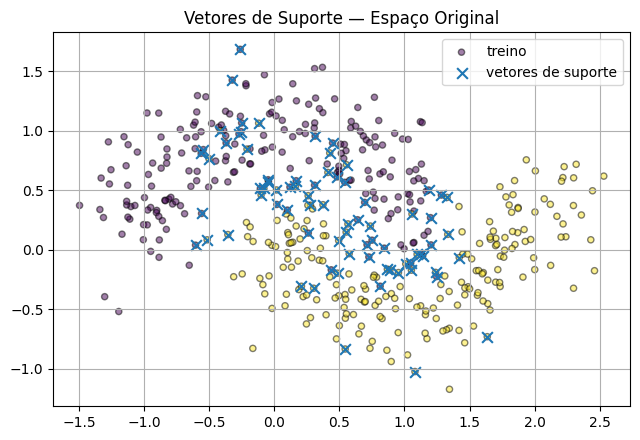

In [33]:
scaler = best_svm.named_steps['scaler']
sv_scaled = best_svm.named_steps['clf'].support_vectors_
sv = scaler.inverse_transform(sv_scaled)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
ax.scatter(X_tr[:,0], X_tr[:,1], c=y_tr, s=20, marker='o', edgecolor='k', alpha=0.5, label='treino')
ax.scatter(sv[:,0], sv[:,1], s=60, marker='x', label='vetores de suporte')
ax.set_title('Vetores de Suporte — Espaço Original'); ax.legend()
plt.tight_layout(); plt.show()